In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv("aisdk-2026-09-11.csv")

In [3]:
df.head()

,# Timestamp,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,...,Length,Type of position fixing device,Draught,Destination,ETA,Data source type,A,B,C,D
0,11/09/2026 00:00:00,Class A,244740921,54.636435,11.387692,Under way using engine,0.0,0.0,335.9,23.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
1,11/09/2026 00:00:00,Class A,257186000,55.745477,10.502223,Under way using engine,0.0,10.2,354.4,351.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
2,11/09/2026 00:00:00,Base Station,2190064,56.716568,11.519052,Unknown value,NaN,NaN,NaN,NaN,...,NaN,GPS,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
3,11/09/2026 00:00:00,Class A,219167000,54.938815,13.987852,Under way using engine,0.0,0.5,39.0,345.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN
4,11/09/2026 00:00:00,Class A,257186000,55.745477,10.502223,Under way using engine,0.0,10.2,354.4,351.0,...,NaN,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN


In [3]:
df.shape

(19065231, 26)

In [4]:
df["Type of mobile"].unique()

array(['Class A', 'Base Station', 'Class B', 'AtoN', 'SAR Airborne',
       'Search and Rescue Transponder', 'Emergency PIRB'], dtype=object)

In [5]:
df.isnull().sum()

# Timestamp                              0
Type of mobile                           0
MMSI                                     0
Latitude                                 0
Longitude                                0
Navigational status                      0
ROT                                6983430
SOG                                1380836
COG                                2849053
Heading                            5048155
IMO                                      0
Callsign                                 0
Name                               1300545
Ship type                                0
Cargo type                        16152476
Width                              1968008
Length                             1964066
Type of position fixing device           0
Draught                            6135608
Destination                           9827
ETA                                7818892
Data source type                         0
A                                  2009481
B          

In [6]:
df1 = df[df["Type of mobile"].isin(["Class A", "Class B"])]


In [7]:
df1.shape

(17748255, 26)

In [8]:
import numpy as np
df1 = df1.copy()                                    
df1["Latitude"] = df1["Latitude"].replace(91.0, np.nan)


In [9]:
df1["Latitude"].isna().sum()     # should equal the count you just measured
df1["Latitude"].describe()       # max should now be ~58, not 91


count    1.773176e+07
mean     5.608139e+01
std      1.154153e+00
min      2.279226e+01
25%      5.504184e+01
50%      5.596575e+01
75%      5.729669e+01
max      6.656435e+01
Name: Latitude, dtype: float64

In [10]:
df1[["Latitude", "Longitude"]].quantile([0, 0.0001, 0.001, 0.5, 0.999, 0.9999, 1])


,Latitude,Longitude
0.0000,22.792258,-160.443535
0.0001,53.640937,0.000000
0.0010,53.851748,3.349023
0.5000,55.965753,10.844100
0.9990,58.365101,15.982242
0.9999,58.719572,16.334547
1.0000,66.564348,123.094790


In [11]:
df1.loc[df1["Latitude"].isna(), "Longitude"] = np.nan


In [12]:
df1[["Latitude", "Longitude"]].quantile([0, 0.0001, 0.001, 0.5, 0.999, 0.9999, 1])

,Latitude,Longitude
0.0000,22.792258,-160.443535
0.0001,53.640937,3.349043
0.0010,53.851748,4.216500
0.5000,55.965753,10.846370
0.9990,58.365101,15.982394
0.9999,58.719572,16.334689
1.0000,66.564348,123.094790


In [13]:
BOX = dict(lat_min=53.0, lat_max=59.5, lon_min=2.0, lon_max=17.0)

in_box = (df1["Latitude"].between(BOX["lat_min"], BOX["lat_max"]) &
          df1["Longitude"].between(BOX["lon_min"], BOX["lon_max"]))

df1["position_suspect"] = ~in_box & df1["Latitude"].notna()
df1["position_suspect"].sum()


73

In [16]:
in_box

0           True
1           True
3           True
4           True
5           True
            ... 
19065226    True
19065227    True
19065228    True
19065229    True
19065230    True
Length: 17748255, dtype: bool

In [14]:
df1.shape

(17748255, 27)

In [15]:
df1.head()

,# Timestamp,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,...,Type of position fixing device,Draught,Destination,ETA,Data source type,A,B,C,D,position_suspect
0,11/09/2026 00:00:00,Class A,244740921,54.636435,11.387692,Under way using engine,0.0,0.0,335.9,23.0,...,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN,False
1,11/09/2026 00:00:00,Class A,257186000,55.745477,10.502223,Under way using engine,0.0,10.2,354.4,351.0,...,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN,False
3,11/09/2026 00:00:00,Class A,219167000,54.938815,13.987852,Under way using engine,0.0,0.5,39.0,345.0,...,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN,False
4,11/09/2026 00:00:00,Class A,257186000,55.745477,10.502223,Under way using engine,0.0,10.2,354.4,351.0,...,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN,False
5,11/09/2026 00:00:00,Class A,257186000,55.745477,10.502223,Under way using engine,0.0,10.2,354.4,351.0,...,Undefined,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN,False


In [17]:
df1[df1["position_suspect"]][["# Timestamp", "MMSI", "Name", "Latitude", "Longitude", "SOG"]]


,# Timestamp,MMSI,Name,Latitude,Longitude,SOG
298552,11/09/2026 00:24:56,304217000,NaN,57.399807,21.581670,0.0
1300450,11/09/2026 01:48:24,160854048,NaN,54.299580,123.094790,16.6
1741719,11/09/2026 02:24:44,209276000,ELBWAVE,57.030902,24.084627,5.8
1741721,11/09/2026 02:24:44,209276000,ELBWAVE,57.030902,24.084627,5.8
1741722,11/09/2026 02:24:44,209276000,ELBWAVE,57.030902,24.084627,5.8
...,...,...,...,...,...,...
16641226,11/09/2026 20:50:33,563087500,NaN,55.418408,17.097037,0.9
16643416,11/09/2026 20:50:43,563087500,NaN,55.418417,17.097110,0.9
18222623,11/09/2026 22:54:22,255806476,SKALAR,54.638858,19.063183,14.4
18222625,11/09/2026 22:54:22,255806476,SKALAR,54.638858,19.063183,14.4


In [18]:
df1["Timestamp"] = pd.to_datetime(df1["# Timestamp"], format="%d/%m/%Y %H:%M:%S")


In [19]:
df1.head()

,# Timestamp,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,...,Draught,Destination,ETA,Data source type,A,B,C,D,position_suspect,Timestamp
0,11/09/2026 00:00:00,Class A,244740921,54.636435,11.387692,Under way using engine,0.0,0.0,335.9,23.0,...,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN,False,2026-09-11
1,11/09/2026 00:00:00,Class A,257186000,55.745477,10.502223,Under way using engine,0.0,10.2,354.4,351.0,...,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN,False,2026-09-11
3,11/09/2026 00:00:00,Class A,219167000,54.938815,13.987852,Under way using engine,0.0,0.5,39.0,345.0,...,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN,False,2026-09-11
4,11/09/2026 00:00:00,Class A,257186000,55.745477,10.502223,Under way using engine,0.0,10.2,354.4,351.0,...,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN,False,2026-09-11
5,11/09/2026 00:00:00,Class A,257186000,55.745477,10.502223,Under way using engine,0.0,10.2,354.4,351.0,...,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN,False,2026-09-11


In [29]:
df1["Timestamp"].dtype
df1["Timestamp"].min(), df1["Timestamp"].max()



(Timestamp('2026-09-11 00:00:00'), Timestamp('2026-09-11 23:59:58'))

In [23]:
df1

,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,IMO,...,Draught,Destination,ETA,Data source type,A,B,C,D,position_suspect,Timestamp
0,Class A,244740921,54.636435,11.387692,Under way using engine,0.0,0.0,335.9,23.0,Unknown,...,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN,False,2026-09-11 00:00:00
1,Class A,257186000,55.745477,10.502223,Under way using engine,0.0,10.2,354.4,351.0,Unknown,...,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN,False,2026-09-11 00:00:00
3,Class A,219167000,54.938815,13.987852,Under way using engine,0.0,0.5,39.0,345.0,Unknown,...,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN,False,2026-09-11 00:00:00
4,Class A,257186000,55.745477,10.502223,Under way using engine,0.0,10.2,354.4,351.0,Unknown,...,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN,False,2026-09-11 00:00:00
5,Class A,257186000,55.745477,10.502223,Under way using engine,0.0,10.2,354.4,351.0,Unknown,...,NaN,Unknown,NaN,AIS,NaN,NaN,NaN,NaN,False,2026-09-11 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19065226,Class A,219019887,55.864783,10.548983,Under way using engine,0.0,0.0,8.0,8.0,9692806,...,2.8,SAELVIG>HOU>SAELVIG,31/12/2026 15:30:00,AIS,50.0,50.0,9.0,9.0,False,2026-09-11 23:59:58
19065227,Class A,265036400,57.682077,11.871850,Under way using engine,0.0,0.0,NaN,97.0,Unknown,...,NaN,Unknown,NaN,AIS,13.0,5.0,4.0,2.0,False,2026-09-11 23:59:58
19065228,Class A,273250200,56.183183,12.359117,Under way using engine,0.0,11.8,129.7,127.0,8729664,...,6.5,S.PETERSBURG,14/09/2026 15:00:00,AIS,44.0,61.0,13.0,3.0,False,2026-09-11 23:59:58
19065229,Class A,247389200,54.838767,10.860792,Under way using engine,1.1,14.5,189.2,190.0,9781865,...,8.6,DEKEL,12/09/2026 02:15:00,AIS,33.0,304.0,29.0,29.0,False,2026-09-11 23:59:58


In [24]:
# 1. rows that are identical in every column
df1.duplicated().sum()


6537569

In [31]:
# 2. rows with the same ship and same second (other values may differ)
df1.duplicated(subset=["MMSI", "Timestamp"]).sum()


56069

In [26]:
df1 = df1.drop_duplicates()
df1.shape


(11210686, 27)

In [36]:
conflicts = df1[df1.duplicated(subset=["MMSI", "Timestamp"], keep= False)]
conflicts = conflicts.sort_values(["MMSI", "Timestamp"])
print(len(conflicts))
conflicts.head(6)


110962


,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,IMO,...,Draught,Destination,ETA,Data source type,A,B,C,D,position_suspect,Timestamp
310306,Class A,3638,55.332245,10.964905,Unknown value,NaN,0.0,0.0,NaN,Unknown,...,NaN,HOME,NaN,AIS,10.0,20.0,30.0,40.0,False,2026-09-11 00:25:56
310323,Class A,3638,55.332248,10.964908,Unknown value,NaN,0.0,0.0,NaN,Unknown,...,NaN,HOME,NaN,AIS,10.0,20.0,30.0,40.0,False,2026-09-11 00:25:56
743069,Class A,3638,55.332267,10.964885,Unknown value,NaN,0.0,0.0,NaN,Unknown,...,NaN,HOME,NaN,AIS,10.0,20.0,30.0,40.0,False,2026-09-11 01:01:46
743075,Class A,3638,55.332267,10.964887,Unknown value,NaN,0.0,0.0,NaN,Unknown,...,NaN,HOME,NaN,AIS,10.0,20.0,30.0,40.0,False,2026-09-11 01:01:46
815397,Class A,3638,55.332240,10.964882,Unknown value,NaN,0.0,0.0,NaN,Unknown,...,NaN,HOME,NaN,AIS,10.0,20.0,30.0,40.0,False,2026-09-11 01:07:45
815404,Class A,3638,55.332242,10.964882,Unknown value,NaN,0.0,0.0,NaN,Unknown,...,NaN,HOME,NaN,AIS,10.0,20.0,30.0,40.0,False,2026-09-11 01:07:45


In [37]:
conflicts.groupby(["MMSI", "Timestamp"]).nunique().gt(1).sum()


Type of mobile                      220
Latitude                          31726
Longitude                         33840
Navigational status                  14
ROT                                3588
SOG                               12397
COG                               28921
Heading                           10354
IMO                                  70
Callsign                            918
Name                                574
Ship type                           293
Cargo type                            0
Width                                 3
Length                              106
Type of position fixing device     1235
Draught                               8
Destination                         103
ETA                                  32
Data source type                      0
A                                   129
B                                    32
C                                    73
D                                    73
position_suspect                      4


In [38]:
tm = conflicts.groupby(["MMSI", "Timestamp"])["Type of mobile"].transform("nunique") > 1
conflicts[tm][["MMSI", "Timestamp", "Type of mobile", "Name", "Latitude", "Longitude", "SOG"]].head(20)


,MMSI,Timestamp,Type of mobile,Name,Latitude,Longitude,SOG
885682,210155000,2026-09-11 01:13:35,Class B,ECO CORSAIR,57.693492,10.590688,0.0
885788,210155000,2026-09-11 01:13:35,Class A,ECO CORSAIR,57.693518,10.590625,0.1
1961358,210586000,2026-09-11 02:42:39,Class B,LOTTA,55.544350,4.869293,6.6
1961401,210586000,2026-09-11 02:42:39,Class A,LOTTA,55.544350,4.869293,6.6
5543626,211163200,2026-09-11 07:17:45,Class A,HALVAR,54.411667,10.215000,5.0
5543648,211163200,2026-09-11 07:17:45,Class B,HALVAR,54.411967,10.214337,4.8
5094965,211234890,2026-09-11 06:45:07,Class B,ILLUSION,55.482873,9.663152,3.6
5095006,211234890,2026-09-11 06:45:07,Class A,ILLUSION,55.483333,9.663333,4.0
8921666,211449790,2026-09-11 11:26:28,Class A,SY AUDIEKEEN,55.008333,10.775000,4.0
8921706,211449790,2026-09-11 11:26:28,Class B,SY AUDIEKEEN,55.008865,10.774387,4.3


In [39]:
print(len(conflicts))
print(tm.sum())
print(conflicts.groupby(["MMSI", "Timestamp"])["Type of mobile"].nunique().gt(1).sum())


110962
440
220


In [40]:
df1 = df1.drop_duplicates(subset=["MMSI", "Timestamp"], keep="first")
df1.shape


(11154617, 27)

In [41]:
df1["Data source type"].value_counts(dropna=False)


Data source type
AIS    11154617
Name: count, dtype: int64

In [42]:
drop_cols = ["A", "B", "C", "D", "Cargo type", "ETA",
             "Data source type", "Type of position fixing device"]

df1 = df1.drop(columns=drop_cols)
df1.shape


(11154617, 19)

In [43]:
df1.to_parquet("ais_clean_step6.parquet", index=False)


In [44]:
per_min = df1.groupby(["MMSI", df1["Timestamp"].dt.floor("min")]).size()
per_min.describe()


count    2.805253e+06
mean     3.976332e+00
std      3.430890e+00
min      1.000000e+00
25%      1.000000e+00
50%      3.000000e+00
75%      6.000000e+00
max      5.400000e+01
dtype: float64

In [45]:
usable = df1["Latitude"].notna() & ~df1["position_suspect"]
print((~usable).sum())                      # rows set aside

work = df1[usable].sort_values(["MMSI", "Timestamp"])
work["minute"] = work["Timestamp"].dt.floor("min")

ds = work.drop_duplicates(subset=["MMSI", "minute"], keep="first")
ds.shape


12772


(2797130, 20)

In [46]:
ds.to_parquet("Data/ais_1min.parquet", index=False)


In [47]:
ds["MMSI"].nunique()


5612

In [1]:
import pandas as pd 

In [2]:
ds = pd.read_parquet("Data/ais_1min.parquet")
ds.shape

(2797130, 20)

In [3]:
ds.dtypes

Type of mobile                 object
MMSI                            int64
Latitude                      float64
Longitude                     float64
Navigational status            object
ROT                           float64
SOG                           float64
COG                           float64
Heading                       float64
IMO                            object
Callsign                       object
Name                           object
Ship type                      object
Width                         float64
Length                        float64
Draught                       float64
Destination                    object
position_suspect                 bool
Timestamp              datetime64[ns]
minute                 datetime64[ns]
dtype: object

In [4]:
ds.head()

,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,IMO,Callsign,Name,Ship type,Width,Length,Draught,Destination,position_suspect,Timestamp,minute
0,Class A,1111,57.139460,4.055898,Unknown value,NaN,141.0,203.1,NaN,Unknown,R4A,TEST,Undefined,NaN,NaN,NaN,Unknown,False,2026-09-11 14:19:38,2026-09-11 14:19:00
1,Class A,1111,56.904485,3.872533,Unknown value,NaN,141.0,203.0,NaN,Unknown,R4A,TEST,Undefined,NaN,NaN,NaN,Unknown,False,2026-09-11 14:25:41,2026-09-11 14:25:00
2,Class A,1111,56.686995,3.705052,Unknown value,NaN,143.0,202.8,NaN,Unknown,R4A,TEST,Undefined,NaN,NaN,NaN,Unknown,False,2026-09-11 14:31:41,2026-09-11 14:31:00
3,Class A,1111,56.469887,3.539963,Unknown value,NaN,140.0,202.7,NaN,Unknown,R4A,TEST,Undefined,NaN,NaN,NaN,Unknown,False,2026-09-11 14:37:42,2026-09-11 14:37:00
4,Class A,1111,56.230915,3.423377,Unknown value,NaN,127.0,333.6,NaN,Unknown,R4A,TEST,Undefined,NaN,NaN,NaN,Unknown,False,2026-09-11 16:19:23,2026-09-11 16:19:00


In [5]:
ds["MMSI"].nunique()

5612

In [6]:
ds["MMSI"].astype(str).str.len().value_counts().sort_index()


MMSI
4       1448
7       2403
8       2967
9    2790312
Name: count, dtype: int64

In [7]:
valid_mmsi = ds["MMSI"].between(100000000, 799999999)
print("invalid rows:", (~valid_mmsi).sum())
print("invalid ships:", ds.loc[~valid_mmsi, "MMSI"].nunique())


invalid rows: 11299
invalid ships: 21


In [8]:
ds[~valid_mmsi].groupby("MMSI").agg(
    rows=("MMSI", "size"),
    name=("Name", "first"),
    max_sog=("SOG", "max"),
).sort_values("rows", ascending=False).head(15)


,rows,name,max_sog
MMSI,,,
2190045,1440,ESBJERG HARBOUR,0.0
3638,1440,3638,0.0
97000092,1405,KEEP CLEAR 0.25NM 96,18.9
97000105,907,KEEP CLEAR 0.25NM 10,9.9
995002349,783,HPL S SIDE ANCHOR 90,5.8
994002349,696,HPL S FORE ANCHOR 90,9.8
997002349,678,HPL P AFT ANCHOR 62%,2.6
97000091,655,KEEP CLEAR 0.25 N 9%,3.1
992198002,621,FISH FARM 250M 61%,10.5


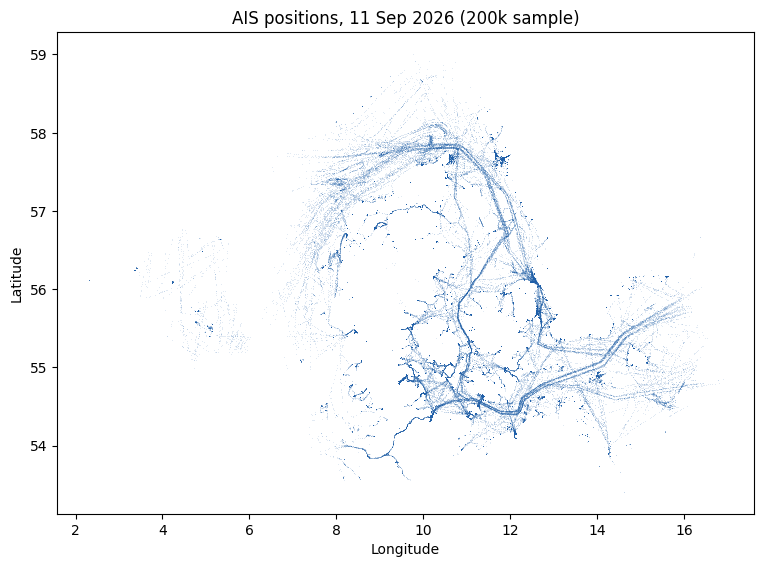

In [10]:
import matplotlib.pyplot as plt

good = ds[~ds["mmsi_invalid"]]
s = good.sample(200_000, random_state=0)

fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(s["Longitude"], s["Latitude"], s=0.3, alpha=0.15, linewidths=0, color="#1f5fa8")
ax.set_aspect(1.8)                      # 1° of longitude is shorter than 1° of latitude at 56°N
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("AIS positions, 11 Sep 2026 (200k sample)")
plt.show()
